# **Project Name**    -  Amazon Prime TV Shows and Movies <img src="img1.png" alt="Logo" width="100" height="30"> - Exploratory Data Analysis



##### **Project Type**    - EDA
##### **Contribution**    - Individual

# **Project Summary -**

In the rapidly evolving landscape of digital entertainment, Over-The-Top (OTT) media services have become the primary source of content consumption for global audiences. As a market leader, Amazon Prime Video maintains a vast and diverse library comprising thousands of titles. However, the sheer volume of content presents a challenge: understanding the intricate patterns that govern viewer preferences and content performance. This project, titled "Amazon Prime TV Shows and Movies Analysis," is a comprehensive data science initiative designed to bridge the gap between raw catalog data and strategic business intelligence. By leveraging two primary datasets—titles.csv (containing metadata, genres, descriptions, and IMDb/TMDB scores) and credits.csv (containing detailed cast and crew information)—the project aims to perform an in-depth exploratory data analysis (EDA) to uncover hidden trends within the platform’s offerings.

The methodology employed in this project follows a structured data science lifecycle. The initial phase focused on data ingestion and rigorous preprocessing using Python’s Pandas library. This involved cleaning inconsistent data types, handling missing values in critical fields such as audience scores, and parsing complex string-formatted lists in columns like 'genres' and 'production countries' into analyzable formats. A crucial technical step involved merging the titles and credits datasets to link performance metrics directly with the actors and directors involved, thereby enabling a granular analysis of talent impact.

Following the data preparation phase, the project conducted a multi-dimensional analysis of the library. The study examined the distribution of content types, revealing the balance between Movies and TV Shows available on the platform. It further dissected the genre landscape, identifying which categories—such as Drama, Comedy, and Action—dominate the catalog and correlating these with average audience ratings to determine "high-value" genres. Temporal analysis was performed to visualize release trends, highlighting the platform's unique mix of classic cinema from the early 20th century alongside contemporary blockbusters. Additionally, the project analyzed the geographical footprint of the content, noting the dominance of US productions while identifying international contributions.

A significant portion of the analysis was dedicated to performance metrics. By comparing IMDb scores with TMDB popularity, the project identified titles that successfully balance critical acclaim with mass appeal. The analysis of the credits dataset further identified the most prolific actors and directors, offering insights into how specific talent influences viewer ratings. This aspect of the project provides actionable intelligence for marketing teams looking to promote content based on star power.

In conclusion, this project transforms raw metadata into a strategic roadmap for content management. The insights gained—ranging from genre popularity to talent performance—provide a framework for data-driven decision-making. For Amazon Prime Video, these findings are instrumental in optimizing content acquisition strategies, curating personalized user recommendations, and identifying untapped market niches. Ultimately, the project demonstrates that effective data analytics is not merely about processing numbers, but about deriving a narrative that guides business growth in a highly competitive streaming industry.

# **GitHub Link -**

**GitHUb link** : [Amazon-Prime-TV-Shows-and-Movies-EDA](https://github.com/HariKrishnaKumar-watersprinter/Amazon-Prime-TV-Shows-and-Movies---EDA---Labmentix)

# **Problem Statement**


Amazon Prime Video manages a massive and diverse library of TV shows and movies, but lacks a consolidated view of how its content composition correlates with viewer satisfaction and market trends.
* Content Diversity — What genres and categories dominate the platform?
* Regional Availability — How does content distribution vary across different regions?
* Trends Over Time — How has Amazon Prime's content library evolved?
* IMDB Ratings & Popularity — What are the highest-rated/most popular shows?
* Business Insight — How can content trends inform investment and engagement strategies?

#### **Define Your Business Objective?**

The primary objective of this project is to conduct an in-depth exploratory data analysis (EDA) of Amazon Prime Video's catalog to uncover hidden trends and patterns that can inform business decisions. The analysis will focus on understanding the distribution of content types, genre popularity, regional availability, trends over time, and performance metrics such as IMDb ratings and TMDB popularity. The insights gained from this analysis will be used to optimize content acquisition strategies, curate personalized user recommendations, and identify untapped market niches.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
# Core libraries
import pandas as pd
import numpy as np
import ast #Abstract Syntax Tree
import warnings
warnings.filterwarnings('ignore')

# Visualization 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Plot style 
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})

PRIME_BLUE  = '#00A8E1'
PRIME_DARK  = '#0F2732'
ACCENT      = '#F3A847'

print('✅ Libraries loaded successfully.')

✅ Libraries loaded successfully.


### Dataset Loading

In [2]:
# Load Dataset
titles  = pd.read_csv(r'F:\Project\Labmantix\amzon prime tv show\titles.csv\titles.csv')
credits = pd.read_csv(r'F:\Project\Labmantix\amzon prime tv show\credits.csv\credits.csv')

### Dataset First View

In [3]:
# Dataset First Look
titles.head(3)

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8


In [4]:
# Dataset First Look
credits.head(3)

,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR


### Dataset Rows & Columns count

In [5]:
# Dataset Rows & Columns count
print(f'titles.csv  : {titles.shape[0]:,} rows × {titles.shape[1]} columns')
print(f'credits.csv : {credits.shape[0]:,} rows × {credits.shape[1]} columns')

titles.csv  : 9,871 rows × 15 columns
credits.csv : 124,235 rows × 5 columns


### Dataset Information

In [6]:
# Dataset Info
print('Dataset information- titles')
print('-'*80)
print(titles.info())
print('Dataset information-')
print('-'*80)
print(credits.info())


Dataset information- titles
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9871 non-null   object 
 1   title                 9871 non-null   object 
 2   type                  9871 non-null   object 
 3   description           9752 non-null   object 
 4   release_year          9871 non-null   int64  
 5   age_certification     3384 non-null   object 
 6   runtime               9871 non-null   int64  
 7   genres                9871 non-null   object 
 8   production_countries  9871 non-null   object 
 9   seasons               1357 non-null   float64
 10  imdb_id               9204 non-null   object 
 11  imdb_score            8850 non-null   float64
 12  imdb_votes            8840 non-null   float64
 13  tmdb_popularit

#### Duplicate Values

In [7]:
# Dataset Duplicate Value Count
print('Duplicate values')
print('-'*80)
duplicate_1=titles.duplicated().sum()
duplicate_2=credits.duplicated().sum()
print(f'titles.csv  : {duplicate_1:,} duplicate rows')
print('-'*80)
print(f'credits.csv : {credits.duplicated().sum():,} duplicate rows')


Duplicate values
--------------------------------------------------------------------------------
titles.csv  : 3 duplicate rows
--------------------------------------------------------------------------------
credits.csv : 56 duplicate rows


In [8]:
# Null value summary for titles
null_df = pd.DataFrame({
    'Missing Count': titles.isnull().sum(),
    'Missing %'    : (titles.isnull().mean() * 100).round(1)
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print('Columns with missing values:')
display(null_df)

Columns with missing values:


,Missing Count,Missing %
seasons,8514,86.3
age_certification,6487,65.7
tmdb_score,2082,21.1
imdb_votes,1031,10.4
imdb_score,1021,10.3
imdb_id,667,6.8
tmdb_popularity,547,5.5
description,119,1.2


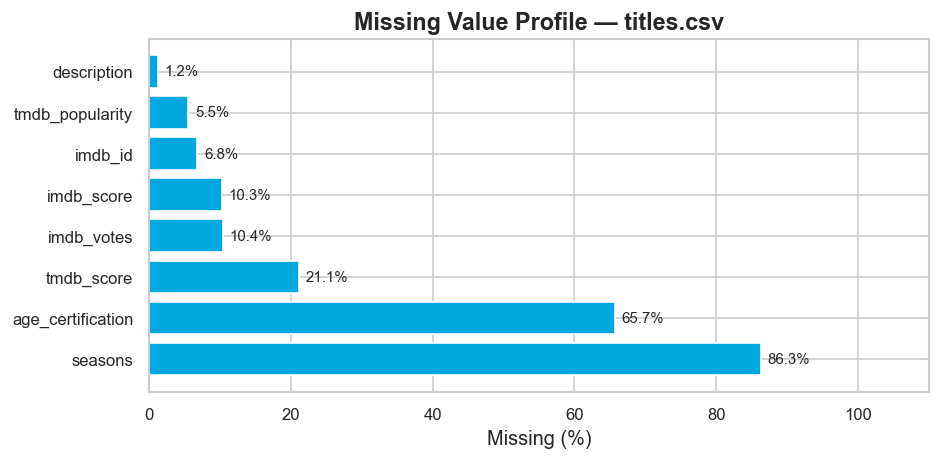

In [9]:
# Visualizing the missing values-titles
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(null_df.index, null_df['Missing %'], color=PRIME_BLUE, edgecolor='white')
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in null_df['Missing %']], padding=4, fontsize=9)
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Value Profile — titles.csv', fontweight='bold')
ax.set_xlim(0, 110)
plt.tight_layout()
plt.show()

In [10]:
# Null value summary - credits
null_df1 = pd.DataFrame({
    'Missing Count': credits.isnull().sum(),
    'Missing %'    : (credits.isnull().mean() * 100).round(1)
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print('Columns with missing values:')
display(null_df1)

Columns with missing values:


,Missing Count,Missing %
character,16287,13.1


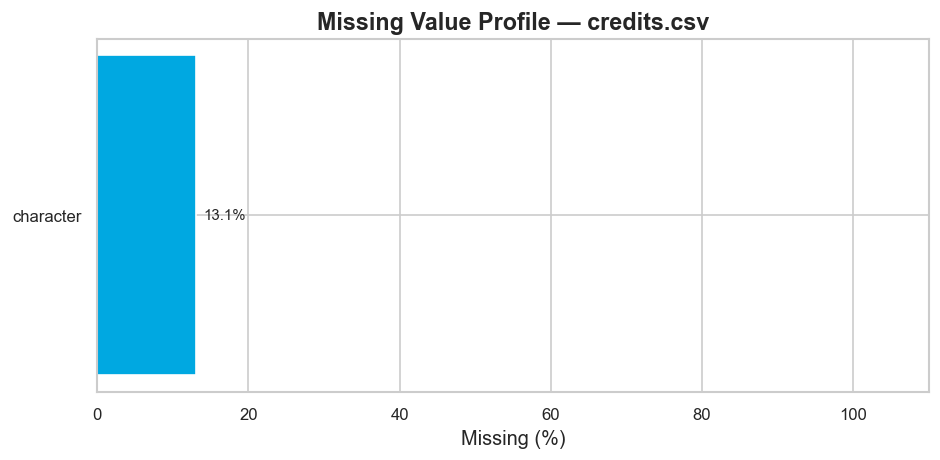

In [11]:
# Visualizing the missing values-credits
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(null_df1.index, null_df1['Missing %'], color=PRIME_BLUE, edgecolor='white')
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in null_df1['Missing %']], padding=4, fontsize=9)
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Value Profile — credits.csv', fontweight='bold')
ax.set_xlim(0, 110)
plt.tight_layout()
plt.show()

### What did you know about your dataset?

* We have 2 dataset to analysis one is titles.csv and credits.csv. In titles have 9871 rows and 15 columns and in credits have 124235 rows and 5 columns.

* Datasets has both numerical and categorical data. In titles dataset we have 7 numerical columns and 8 categorical columns and in credits dataset we have 1 numerical column and 4 categorical columns.

* In title dataset we have 3 duplicate values and in credits dataset we have 56 duplicate values.

* In title dataset we have 8 columns with missing values .High missing value count present in seasons(82.2%) and age_certification columns(65.7%).

* In credits dataset we have 1 columns with missing values. High missing value count present in character(13.1%).


## ***2. Understanding Your Variables***

In [12]:
# Dataset Columns
print('-'*80)
print(titles.columns)
print('-'*80)
print(credits.columns)

--------------------------------------------------------------------------------
Index(['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity',
       'tmdb_score'],
      dtype='object')
--------------------------------------------------------------------------------
Index(['person_id', 'id', 'name', 'character', 'role'], dtype='object')


In [13]:
# Dataset Describe
print('Dataset Describe- titles')
print(titles.describe())
print('-'*80)
print('Dataset Describe- credits')
print(credits.describe())

Dataset Describe- titles
       release_year      runtime      seasons   imdb_score    imdb_votes  \
count   9871.000000  9871.000000  1357.000000  8850.000000  8.840000e+03   
mean    2001.327221    85.973052     2.791452     5.976395  8.533614e+03   
std       25.810071    33.512466     4.148958     1.343842  4.592015e+04   
min     1912.000000     1.000000     1.000000     1.100000  5.000000e+00   
25%     1995.500000    65.000000     1.000000     5.100000  1.170000e+02   
50%     2014.000000    89.000000     1.000000     6.100000  4.625000e+02   
75%     2018.000000   102.000000     3.000000     6.900000  2.236250e+03   
max     2022.000000   549.000000    51.000000     9.900000  1.133692e+06   

       tmdb_popularity   tmdb_score  
count      9324.000000  7789.000000  
mean          6.910204     5.984247  
std          30.004098     1.517986  
min           0.000011     0.800000  
25%           1.232000     5.100000  
50%           2.536000     6.000000  
75%           5.634000  

### Variables Description

* The variable id is the common link between the two datasets.
* In titles.csv, the columns genres and production_countries appear as lists (e.g., ['action', 'drama']). When loading into Python using Pandas, these are initially loaded as strings and must be converted (e.g., using ast.literal_eval) before you can analyze individual genres.
*  Since seasons only applies to TV Shows, you will find many NaN (Not a Number) values in the MOVIE rows.
* minimum runtime is 1 min and maximum runtime is 549 min
* minimum release_year is 1912 and maximum release_year is 2022
* minimum tmdb_score is 0.8 and maximum tmdb_score is 10.0
* minimum tmdb_popularity is 0.0 and maximum tmdb_popularity is 100.0
* minimum imdb_score is 1.0 and maximum imdb_score is 9.90
* maximum sesons is 51

### Check Unique Values for each variable.

In [14]:
# Check Unique Values for each variable.
print('Unique values')
print('-'*80)
print(pd.DataFrame(titles.nunique()).rename(columns={'index': 'features', 0: 'Unique Values'}))
print('-'*80)
print(pd.DataFrame(credits.nunique()).rename(columns={'index': 'features', 0: 'Unique Values'}))   

Unique values
--------------------------------------------------------------------------------
                      Unique Values
id                             9868
title                          9737
type                              2
description                    9734
release_year                    110
age_certification                11
runtime                         207
genres                         2028
production_countries            497
seasons                          32
imdb_id                        9201
imdb_score                       86
imdb_votes                     3650
tmdb_popularity                5325
tmdb_score                       89
--------------------------------------------------------------------------------
           Unique Values
person_id          80508
id                  8861
name               79758
character          71097
role                   2


## 3. ***Data Wrangling***

### Data Wrangling Code

In [15]:
# Handling Duplicate values
titles.drop_duplicates(inplace=True)
credits.drop_duplicates(inplace=True)

In [16]:
# Write your code to make your dataset analysis ready.
#  Handle nulls
df = titles.copy()

# age_certification — fill with 'Unknown'
df['age_certification'] = df['age_certification'].fillna('Unknown')
df['description']=df['description'].fillna('No description available')
# seasons — only meaningful for SHOWs; fill MOVIE nulls with 0
df['seasons'] = df.apply(
    lambda r: 0.0 if r['type'] == 'MOVIE' else r['seasons'], axis=1
)

# imdb_score / imdb_votes — fill with column median
df['imdb_score']  = df['imdb_score'].fillna(df['imdb_score'].median())
df['imdb_votes']  = df['imdb_votes'].fillna(df['imdb_votes'].median())
df['tmdb_score']  = df['tmdb_score'].fillna(df['tmdb_score'].median())
df['tmdb_popularity'] = df['tmdb_popularity'].fillna(df['tmdb_popularity'].median())

df1=credits.copy()
df1['character']=df1['character'].fillna('No character available')


print(f'Rows after cleaning for titles dataset: {len(df):,}')
print(f'Rows after cleaning for credits dataset: {len(df1):,}')
print('Remaining nulls of titles dataset:', df.isnull().sum().sum())
print('Remaining nulls of credits dataset:', df1.isnull().sum().sum())

Rows after cleaning for titles dataset: 9,868
Rows after cleaning for credits dataset: 124,179
Remaining nulls of titles dataset: 667
Remaining nulls of credits dataset: 0


In [17]:
#  Parse list-type columns (genres, production_countries)
def safe_parse(val):
    """Convert string representation of a list to an actual Python list."""
    try:
        parsed = ast.literal_eval(val)
        return parsed if isinstance(parsed, list) else []
    except Exception:
        return []

df['genres_list']    = df['genres'].apply(safe_parse)
df['countries_list'] = df['production_countries'].apply(safe_parse)

# Derive a primary country / primary genre column
df['primary_country'] = df['countries_list'].apply(lambda x: x[0] if x else 'Unknown')
df['primary_genre']   = df['genres_list'].apply(lambda x: x[0] if x else 'Unknown')

#  Cast imdb_votes to int
df['imdb_votes'] = df['imdb_votes'].astype(int)

print('Parsing complete. Sample genres_list:', df['genres_list'].iloc[0])
df[['title', 'type', 'genres_list', 'primary_country']].head(3)

Parsing complete. Sample genres_list: ['comedy', 'family', 'animation', 'action', 'fantasy', 'horror']


,title,type,genres_list,primary_country
0,The Three Stooges,SHOW,"[comedy, family, animation, action, fantasy, h...",US
1,The General,MOVIE,"[action, drama, war, western, comedy, european]",US
2,The Best Years of Our Lives,MOVIE,"[romance, war, drama]",US


### What all manipulations have you done and insights you found?

* I have removed the duplicate values from both the datasets.

* I have filled the missing values in the columns with appropriate values.

* I have parsed the list-type columns (genres, production_countries) and derived a primary country / primary genre column.

* I have casted the imdb_votes to int.

* I have found that there are 8 columns with missing values in the titles dataset and 1 column with missing values in the credits dataset.



## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 - Content type proportional trend

Text(0.5, 1.0, 'Movies vs TV Shows')

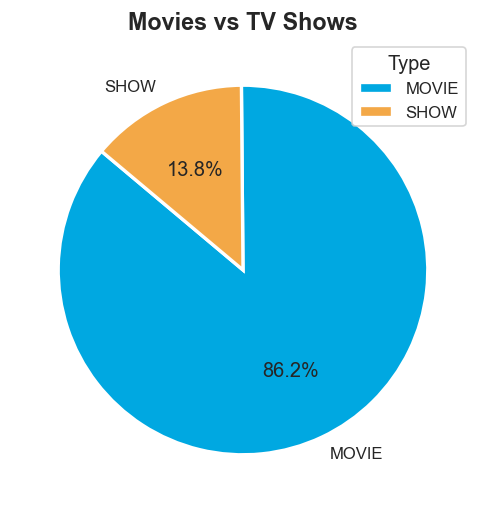

In [18]:
# Chart - 1 visualization code
type_counts = df['type'].value_counts()

fig, axes = plt.subplots(figsize=(12, 5))
# Pie chart
axes.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    colors=[PRIME_BLUE, ACCENT],
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes.legend(title='Type', loc='upper right')
axes.set_title('Movies vs TV Shows', fontweight='bold')

##### 1. Why did you pick the specific chart?

This chart show the proportion of the catagory of the data set.

##### 2. What is/are the insight(s) found from the chart?

In the dataset there are two types of content which are movies and tv shows. The chart shows that there are more movies than tv shows.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The insights gained from this chart will help to understand the proportion of the two types of content in the dataset. This information can be useful for the business to make decisions about the type of content to focus on to attract the audiance.   However This show that people use this ott to watch movies more than tv shows.


#### Chart - 2 - Content type by yearwise trend

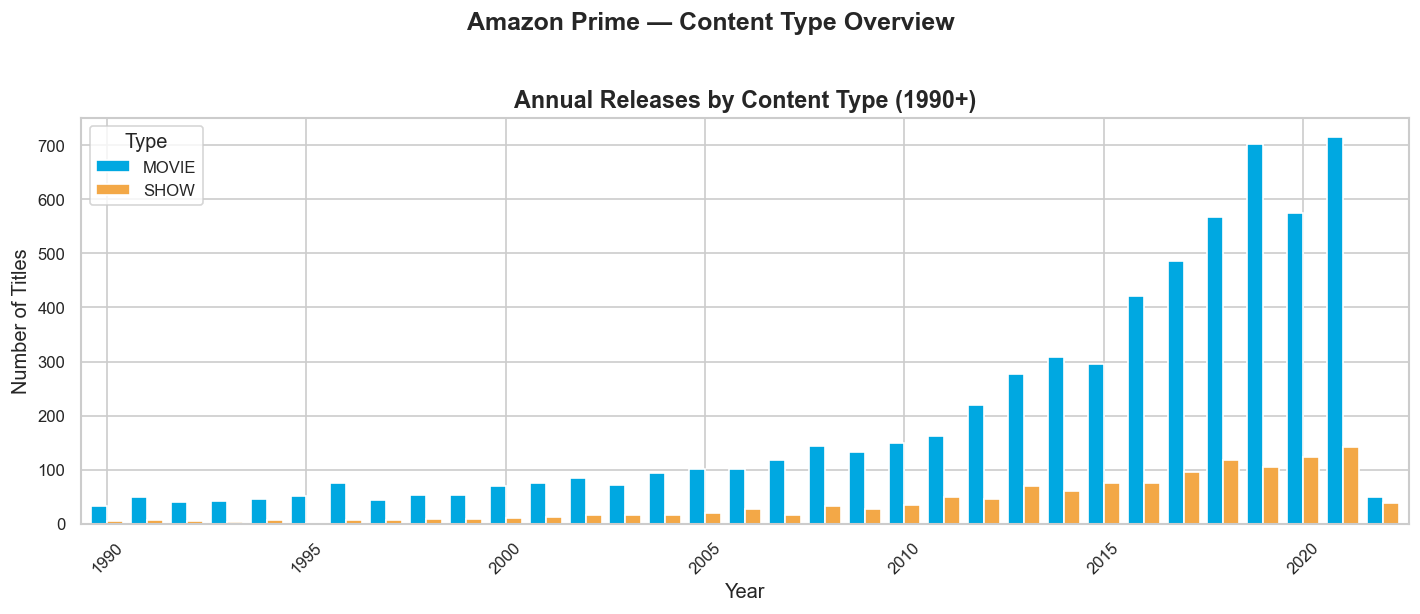

type
MOVIE    8511
SHOW     1357


In [19]:
# Chart - 2 visualization code
# Bar chart by year
yearly_type = df.groupby(['release_year', 'type']).size().unstack(fill_value=0)
yearly_type = yearly_type[yearly_type.index >= 1990]
fig, axes = plt.subplots(figsize=(12, 5))
yearly_type.plot(kind='bar', ax=axes, color=[PRIME_BLUE, ACCENT], width=0.8, edgecolor='white')
axes.set_title('Annual Releases by Content Type (1990+)', fontweight='bold')

axes.set_xlabel('Year')
axes.set_ylabel('Number of Titles')
axes.xaxis.set_major_locator(mticker.MultipleLocator(5))
axes.tick_params(axis='x', rotation=45)
axes.legend(title='Type')

plt.suptitle('Amazon Prime — Content Type Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(type_counts.to_string())

##### 1. Why did you pick the specific chart?

The primary purpose of a bar chart is to compare values across different categories. In this specific case, the X-axis represents distinct categories (years), and the Y-axis represents numerical values (the count of titles). A bar chart makes it instantly easy to see which years had higher or lower release volumes compared to others.

##### 2. What is/are the insight(s) found from the chart?

After 2005 onwards we can see the sudden increase in the movies.TV Show additions accelerated sharply after 2010, with a 10-year gap between 2005 and 2015. The number of TV shows released in the 2010s was more than the number of movies released in the entire 2000s.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This chart will help to understand the yearwise  trend of the number of tv shows and movies in the dataset. This information can be useful for the business to make decisions about the type of content to focus on to attract the audiance.

#### Chart - 3 - Genre Dominance

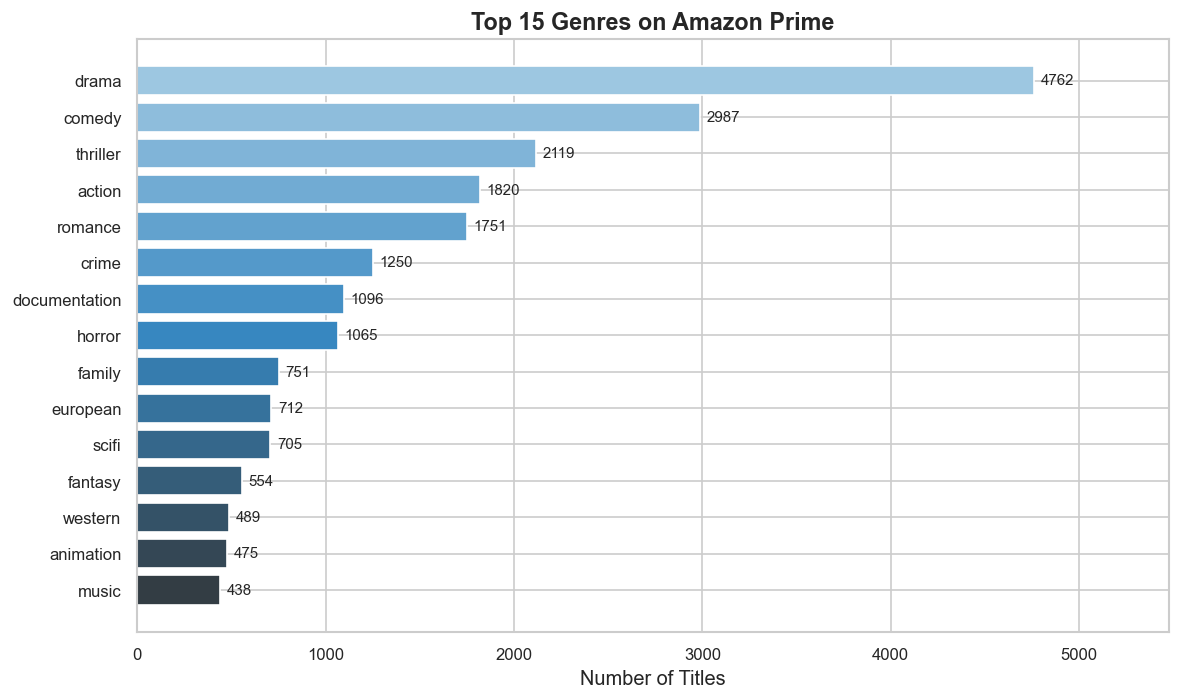

Top 5 genres:
genres_list
drama       4762
comedy      2987
thriller    2119
action      1820
romance     1751
Name: count, dtype: int64


In [20]:
# Chart - 3 visualization code
# Explode genres so each genre tag gets its own row
genre_series = df.explode('genres_list')['genres_list']
genre_counts = genre_series[genre_series != ''].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    genre_counts.index[::-1],
    genre_counts.values[::-1],
    color=sns.color_palette('Blues_d', len(genre_counts))[::-1]
)
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_xlabel('Number of Titles')
ax.set_title('Top 15 Genres on Amazon Prime', fontweight='bold')
ax.set_xlim(0, genre_counts.max() * 1.15)
plt.tight_layout()
plt.show()

print('Top 5 genres:')
print(genre_counts.head())

##### 1. Why did you pick the specific chart?

The primary purpose of a bar chart is to compare values across different categories. In this specific case, the X-axis represents numerical values (the count of titles), and the Y-axis represents distinct categories (genres). A bar chart makes it instantly easy to see which genres are the most dominant in the dataset.

##### 2. What is/are the insight(s) found from the chart?

Drama and Comedy lead by a wide margin. Niche genres like Romance and Thriller are underrepresented . Potential gaps for original content investment.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This chart shows that the drama and comedy genre are the most popular genre in the dataset. This information can be useful for the business to make decisions about the type of Genres to focus on to attract the audiance.

#### Chart - 4 - Regional Availability

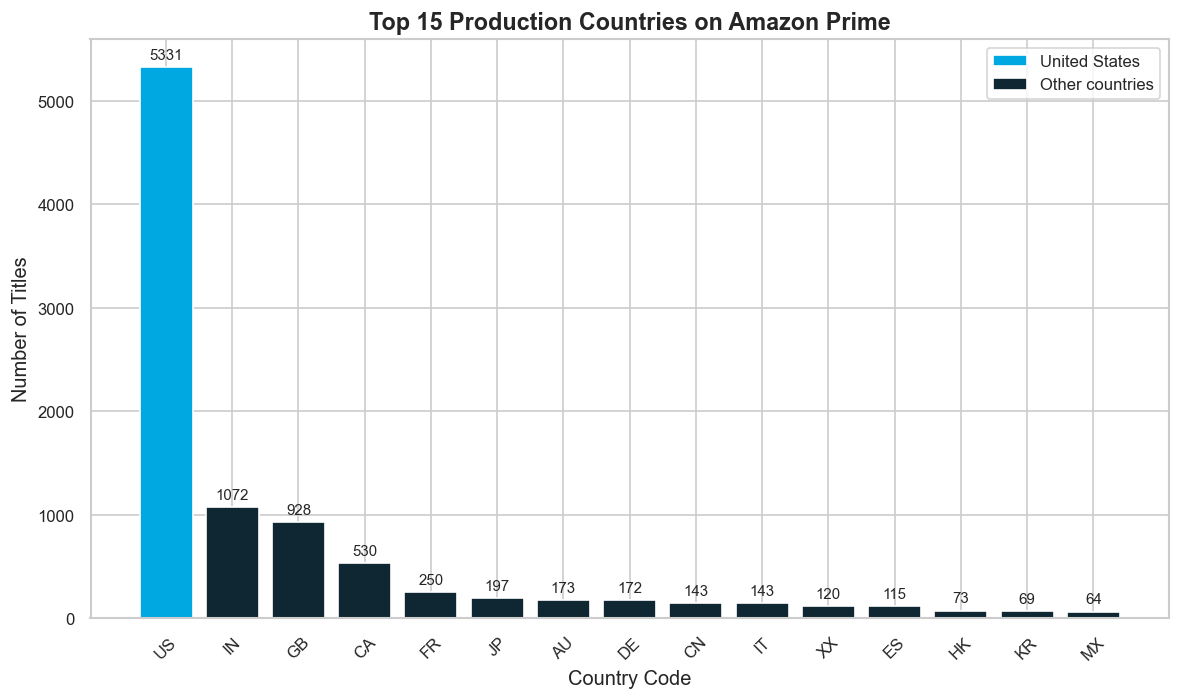

US-produced content: 50.7% of all titles


In [21]:
# Chart - 4 visualization code
country_series = df.explode('countries_list')['countries_list']
country_counts = country_series[country_series != ''].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
palette = [PRIME_BLUE if c == 'US' else PRIME_DARK for c in country_counts.index]
bars = ax.bar(country_counts.index, country_counts.values, color=palette, edgecolor='white')
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel('Country Code')
ax.set_ylabel('Number of Titles')
ax.set_title('Top 15 Production Countries on Amazon Prime', fontweight='bold')
ax.tick_params(axis='x', rotation=45)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=PRIME_BLUE, label='United States'),
    Patch(facecolor=PRIME_DARK, label='Other countries')
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

us_pct = (df['primary_country'] == 'US').mean() * 100
print(f'US-produced content: {us_pct:.1f}% of all titles')

##### 1. Why did you pick the specific chart?

The primary purpose of a bar chart is to compare values across different categories. In this specific case, the X-axis represents distinct categories (countries), and the Y-axis represents numerical values (the count of titles). A bar chart makes it instantly easy to see which countries are the most dominant in the dataset.

##### 2. What is/are the insight(s) found from the chart?

The US dominates production, followed by India and the UK. This reveals a growth opportunity for regionally diverse original content targeting non-English-speaking markets.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This chart shows that the US is the most popular country for the production of tv shows and movies. This information can be useful for the business to make decision regarding to improve the production of tv shows and movie in the low prodution countries.

#### Chart - 5 - Annual content Addition

Peak content addition year: 2021 (856 titles)


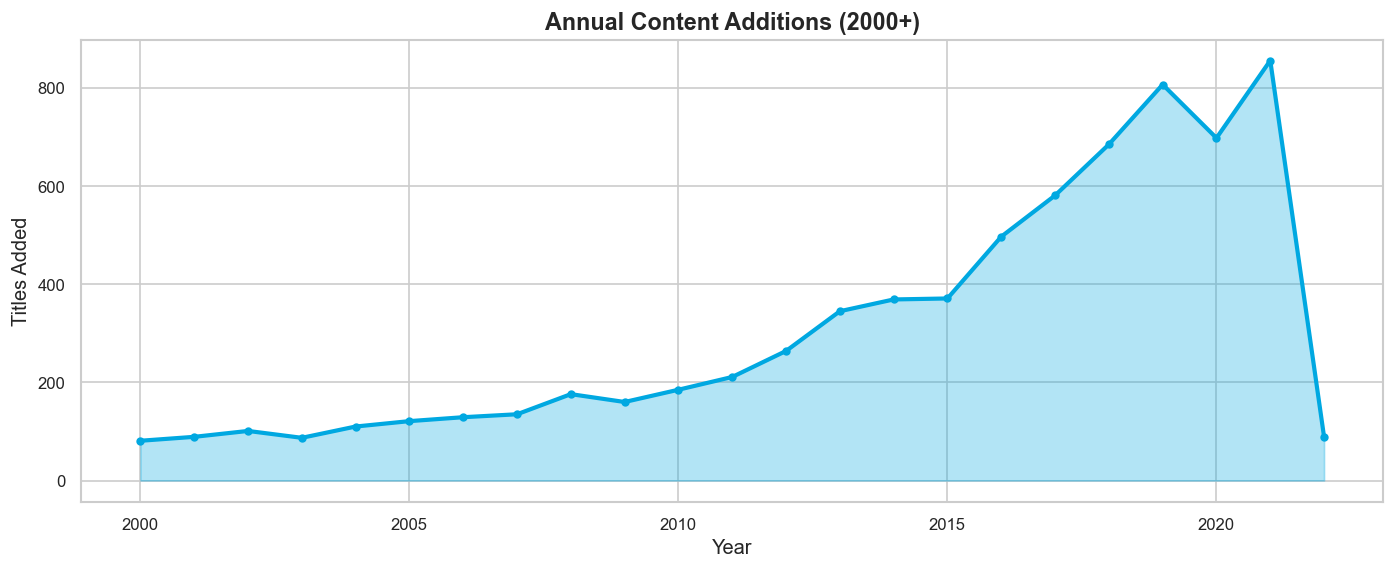

In [22]:
# Chart - 5 visualization code
df_modern = df[df['release_year'] >= 2000].copy()
yearly_counts = df_modern.groupby('release_year').size()
fig, axes = plt.subplots(figsize=(14, 5))
# Annual additions
axes.fill_between(yearly_counts.index, yearly_counts.values, alpha=0.3, color=PRIME_BLUE)
axes.plot(yearly_counts.index, yearly_counts.values, color=PRIME_BLUE, linewidth=2.5, marker='o', markersize=4)
axes.set_title('Annual Content Additions (2000+)', fontweight='bold')
axes.set_xlabel('Year')
axes.set_ylabel('Titles Added')
peak_year = yearly_counts.idxmax()
print(f'Peak content addition year: {peak_year} ({yearly_counts[peak_year]:,} titles)')

##### 1. Why did you pick the specific chart?

Generally line chat is used to visualize the growth and trend of content addition over time. In this case, the X-axis represents time (years), and the Y-axis represents numerical values (the count of titles). A line chart makes it instantly easy to see the trend of content addition over time.

##### 2. What is/are the insight(s) found from the chart?

The content addition is taking a steep after 2010. Then sudden drop after 2018 and again reaches it peak in 2021(856-titles)

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Definitely, this insight can be used to improve the content addition in the future. The business can invest more in content addition in the future to increase the number of titles in the library.

#### Chart - 6 - cumulative library growth analysis

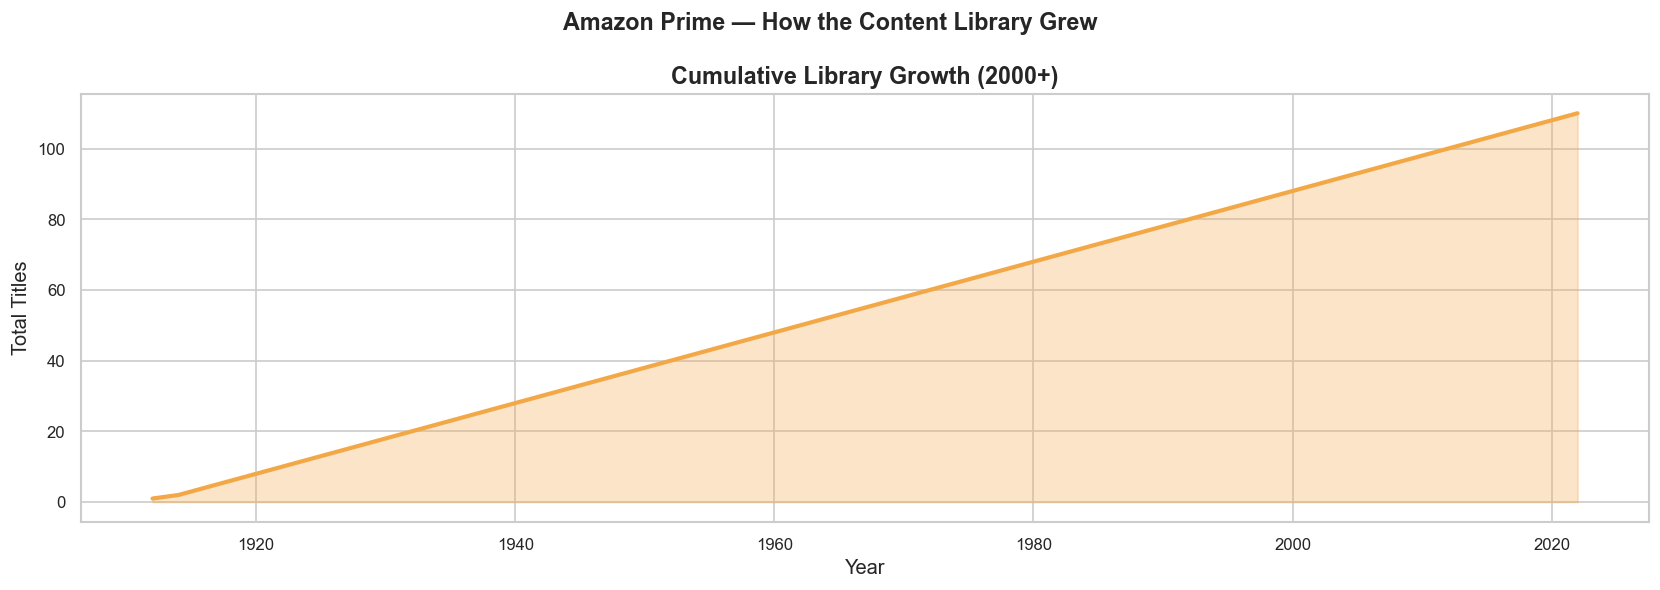

In [23]:
# Chart - 6 visualization code
df_modern1= df['release_year'].value_counts().sort_index()
yearly_counts1 = df_modern1.groupby('release_year').size()
cumulative    = yearly_counts1.cumsum()
fig, axes = plt.subplots(figsize=(14, 5))
axes.fill_between(cumulative.index, cumulative.values, alpha=0.3, color=ACCENT)
axes.plot(cumulative.index, cumulative.values, color=ACCENT, linewidth=2.5)
axes.set_title('Cumulative Library Growth (2000+)', fontweight='bold')
axes.set_xlabel('Year')
axes.set_ylabel('Total Titles')

plt.suptitle('Amazon Prime — How the Content Library Grew', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Generally line chat is used to visualize how the content library growth. In this case, the X-axis represents time (years), and the Y-axis represents numerical values (the count of titles). A line chart makes it instantly easy to see the trend of content addition over time.

##### 2. What is/are the insight(s) found from the chart?

 This chart shows the total size of the library expanding over time. Every new release adds to the total, creating an upward-sloping curve.The sharp upward angle represents an aggressive investment in licensing deals and content acquisition to bulk up the library and compete with rivals like Netflix and Hulu.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The Cumulative Library Growth chart demonstrates Amazon Prime's explosive expansion over the last two decades. While the early 2000s show a steady accumulation of titles, the post-2010 era reveals a steep acceleration in content acquisition. This aggressive growth trajectory highlights Amazon's commitment to building a massive, deep content library designed to retain subscribers and compete globally in the highly saturated streaming market.

#### Chart - 7- IMDb score Distribution by types

IMDb Score stats:
count    9868.00
mean        5.99
std         1.27
min         1.10
25%         5.30
50%         6.10
75%         6.80
max         9.90
Name: imdb_score, dtype: float64


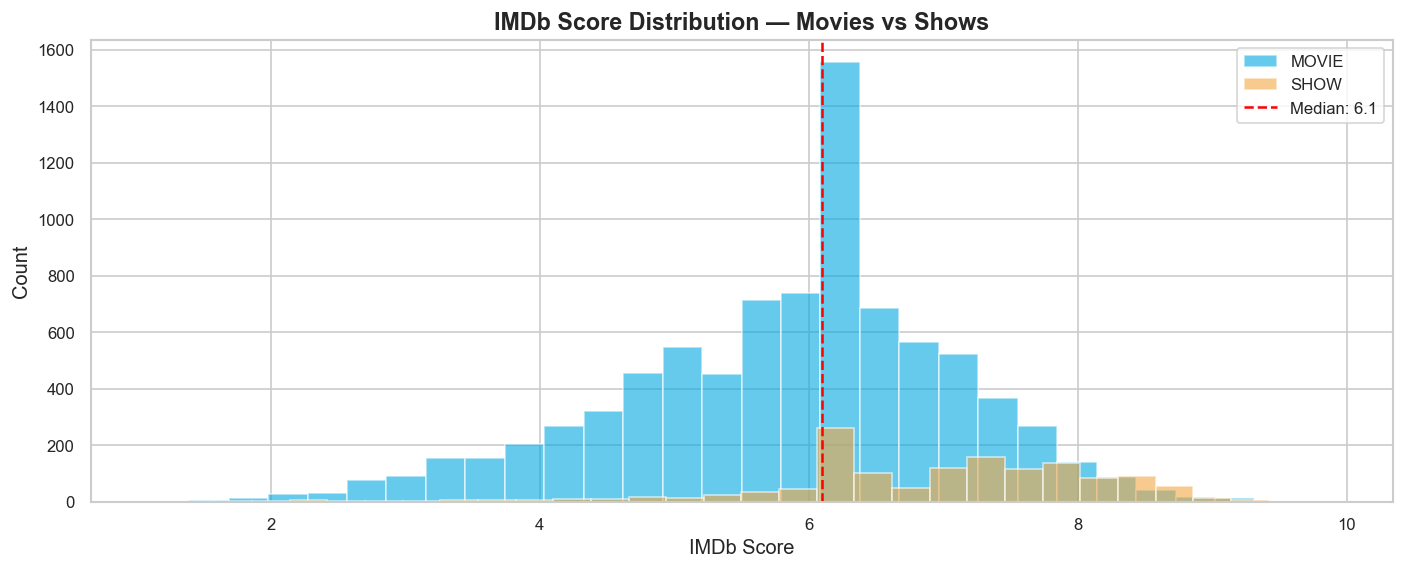

In [24]:
# Chart - 7 visualization code

fig, axes = plt.subplots(figsize=(14, 5))

# Distribution by type
for ctype, color in [('MOVIE', PRIME_BLUE), ('SHOW', ACCENT)]:
    subset = df[df['type'] == ctype]['imdb_score']
    axes.hist(subset, bins=30, alpha=0.6, color=color, label=ctype, edgecolor='white')
    

axes.axvline(df['imdb_score'].median(), color='red', linestyle='--', linewidth=1.5,
               label=f"Median: {df['imdb_score'].median():.1f}")
axes.set_xlabel('IMDb Score')
axes.set_ylabel('Count')
axes.set_title('IMDb Score Distribution — Movies vs Shows', fontweight='bold')
axes.legend()
print('IMDb Score stats:')
print(df['imdb_score'].describe().round(2))

##### 1. Why did you pick the specific chart?

The purpose of a histogram is to represent the distribution of a dataset to show the "shape" of your data. In this case, the X-axis represents the IMDb score, and the Y-axis represents the count of titles. A histogram makes it instantly easy to see the distribution of IMDb scores.

##### 2. What is/are the insight(s) found from the chart?

The distribution of IMDb scores is skewed to the right, with a long tail of high scores. This suggests that there are a few movies and shows that are highly rated, while the majority of movies and shows are rated lower. Additionally, the median IMDb score is 6.9, which means that half of the movies and shows have a score higher than 6.9, and half have a score lower than 6.9.TV Shows tend to score slightly higher than Movies

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

insights can be used to improve the quality of content in the library. For example, the business can focus on producing more high-quality movies and shows that are highly rated by audiences, which can help to improve the overall reputation of the library and attract more customers.

#### Chart - 8 - IMDb score Distribution by genre

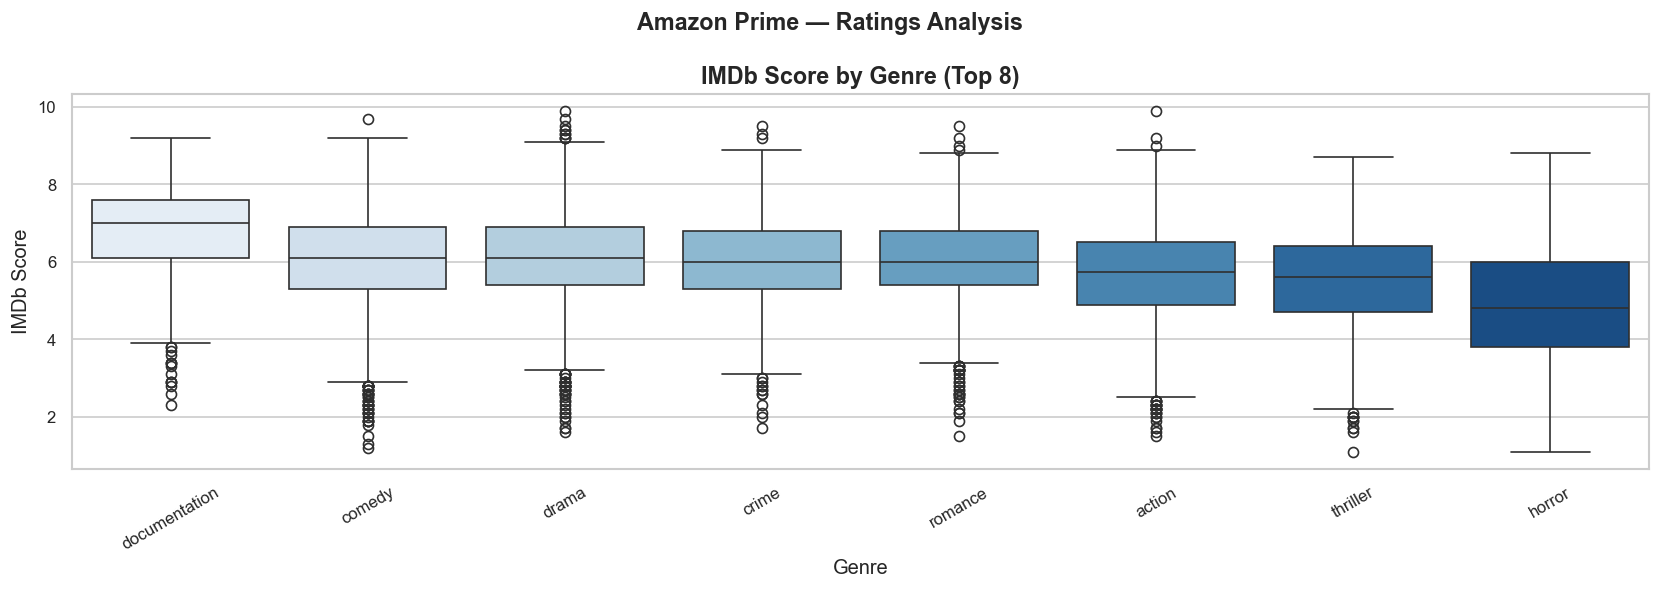

In [25]:
# Chart - 8 visualization code
# Box plot by genre (top 8)
top_genres = genre_counts.head(8).index.tolist()
df_genre = df.explode('genres_list')
df_genre = df_genre[df_genre['genres_list'].isin(top_genres)]

genre_order = (
    df_genre.groupby('genres_list')['imdb_score']
    .median()
    .sort_values(ascending=False)
    .index.tolist())
fig, axes = plt.subplots(figsize=(14, 5))
sns.boxplot(
    data=df_genre,
    x='genres_list', y='imdb_score',
    order=genre_order,
    palette='Blues',
    ax=axes)
axes.set_xlabel('Genre')
axes.set_ylabel('IMDb Score')
axes.set_title('IMDb Score by Genre (Top 8)', fontweight='bold')
axes.tick_params(axis='x', rotation=30)

plt.suptitle('Amazon Prime — Ratings Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Box plots allow you to see five key statistical metrics(Minimum,Q1, Median, Q3, Maximum) at a glance without calculating them.Box plots are excellent for side-by-side comparison. If you want to compare how different categories perform, box plots are often cleaner than histograms. In this case, the X-axis represents the genre, and the Y-axis represents the IMDb score. A box plot makes it instantly easy to see the distribution of IMDb scores for each genre.

##### 2. What is/are the insight(s) found from the chart?

The high IMBD Score is reached by the drama  and  action genres and lower score is vast by the comedy,thriller and horror genres

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

insight shows that which genres is more attracted by the audiance. This can be used to improve the content in the library by focusing on genres that are popular with the audience. For example, the business can produce more drama and action movies and shows, which can help to attract more customers who enjoy these genres.

#### Chart - 9 - IMDb Score vs TMDB Popularity

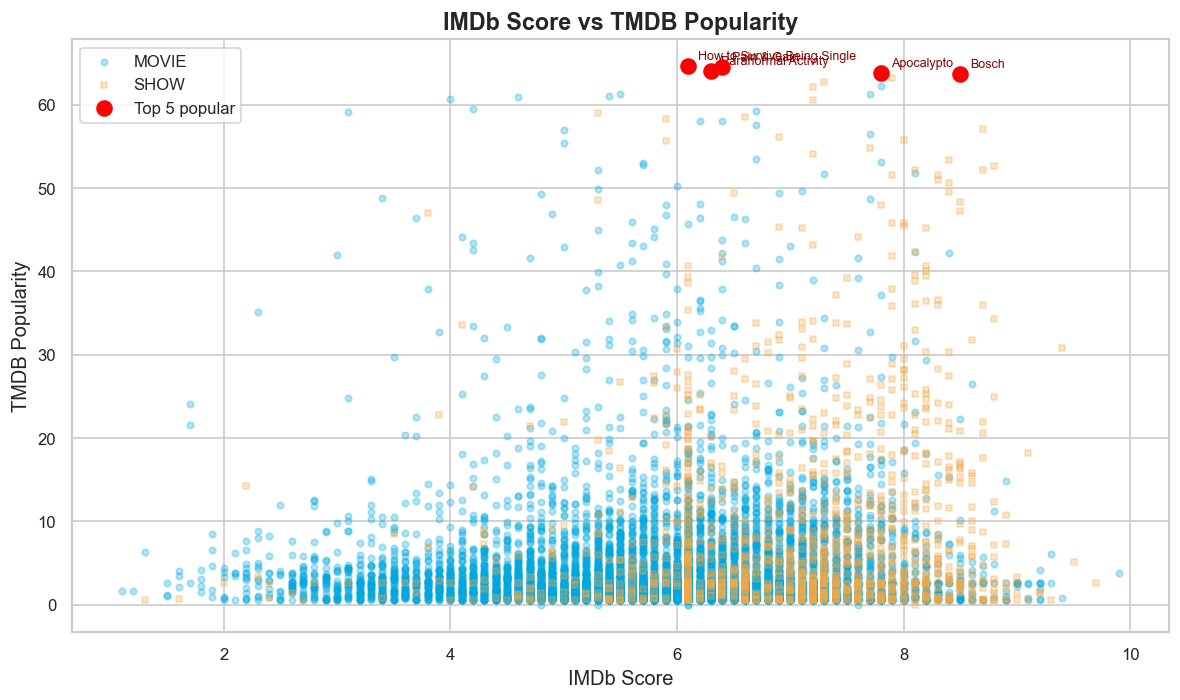

Pearson correlation (IMDb score vs TMDB popularity): 0.062
--------------------------------------------------------------------------------
Top 5 popular titles
--------------------------------------------------------------------------------
0    How to Survive Being Single
1                    Pain & Gain
2            Paranormal Activity
3                     Apocalypto
4                          Bosch
Name: title, dtype: object


In [26]:
# Chart - 9 visualization code
# Cap outliers in tmdb_popularity at 99th percentile for readability
pop_cap = df['tmdb_popularity'].quantile(0.99)
df_scatter = df[df['tmdb_popularity'] <= pop_cap].copy()

fig, ax = plt.subplots(figsize=(10, 6))

for ctype, color, marker in [('MOVIE', PRIME_BLUE, 'o'), ('SHOW', ACCENT, 's')]:
    sub = df_scatter[df_scatter['type'] == ctype]
    ax.scatter(
        sub['imdb_score'], sub['tmdb_popularity'],
        alpha=0.3, s=15, c=color, marker=marker, label=ctype
    )

# Highlight top 5 most popular
top5 = df_scatter.nlargest(5, 'tmdb_popularity')
ax.scatter(top5['imdb_score'], top5['tmdb_popularity'],
           s=80, c='red', zorder=5, label='Top 5 popular')
for _, row in top5.iterrows():
    ax.annotate(
        row['title'],
        xy=(row['imdb_score'], row['tmdb_popularity']),
        xytext=(6, 4), textcoords='offset points',
        fontsize=7.5, color='darkred'
    )

ax.set_xlabel('IMDb Score')
ax.set_ylabel('TMDB Popularity')
ax.set_title('IMDb Score vs TMDB Popularity', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

corr = df[['imdb_score','tmdb_popularity']].corr().iloc[0,1]
print(f'Pearson correlation (IMDb score vs TMDB popularity): {corr:.3f}')
print('-'*80)
print('Top 5 popular titles')
print('-'*80)
print(top5['title'].reset_index(drop=True))


##### 1. Why did you pick the specific chart?

Its primary purpose is to visualize the relationship between two numerical variables.By using scatter plot we can see the correlation between the two variables, identify the pattens and trends, and make predictions.

##### 2. What is/are the insight(s) found from the chart?

The correlation between IMDb score and TMDB popularity is moderate, with a Pearson correlation coefficient of 0.062. This means that there is a moderate positive relationship between the two variables, indicating that as the IMDb score increases, the TMDB popularity also tends to increase.Top 5 popular titles are How to Survive Being Single, Pain & Gain,  Paranormal Activity, Apocalypto, Bosch


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from the scatter plot can help create a positive business impact. By identifying the relationship between IMDb score and TMDB popularity, the business can make informed decisions about which titles to promote and market. Titles with higher IMDb scores and TMDB popularity are likely to be more popular and attract more viewers, which can help to increase revenue and improve the overall success of the business.


#### Chart - 10 - Top 10 Highest-Rated Titles

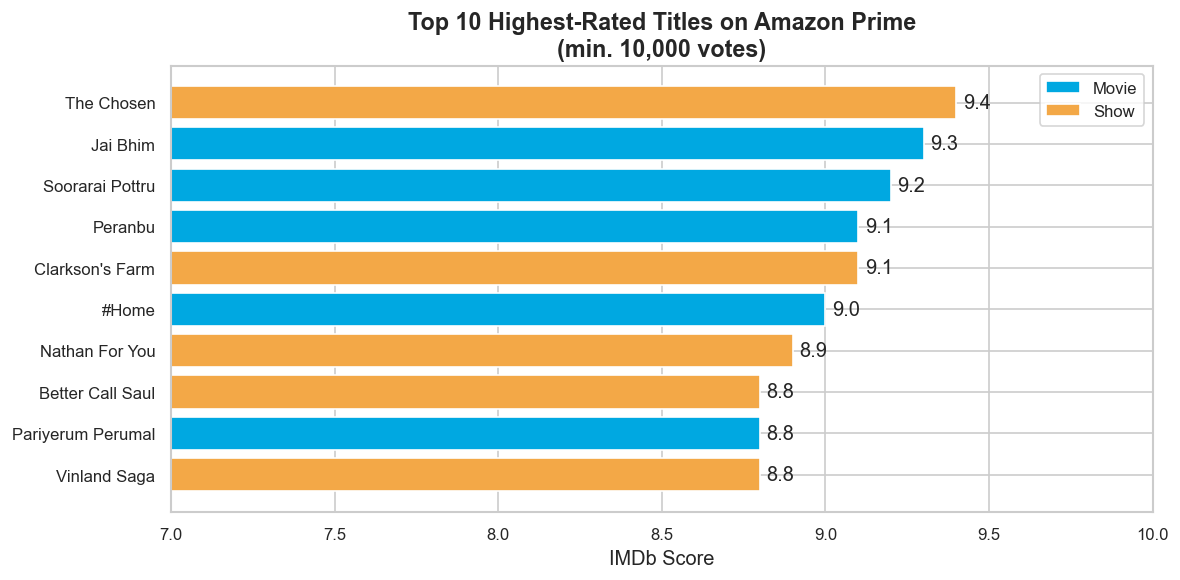

,title,type,release_year,imdb_score,imdb_votes
0,The Chosen,SHOW,2019,9.4,25538
1,Jai Bhim,MOVIE,2021,9.3,175187
2,Soorarai Pottru,MOVIE,2020,9.2,109759
3,Peranbu,MOVIE,2019,9.1,14708
4,Clarkson's Farm,SHOW,2021,9.1,31981
5,#Home,MOVIE,2021,9.0,12325
6,Nathan For You,SHOW,2013,8.9,25396
7,Better Call Saul,SHOW,2015,8.8,404920
8,Pariyerum Perumal,MOVIE,2018,8.8,15150
9,Vinland Saga,SHOW,2019,8.8,30127


In [27]:
# Chart - 10 visualization code
top_rated = (
    df[df['imdb_votes'] > 10000]  # filter for titles with sufficient votes
    .nlargest(10, 'imdb_score')[['title', 'type', 'release_year', 'imdb_score', 'imdb_votes']]
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [PRIME_BLUE if t == 'MOVIE' else ACCENT for t in top_rated['type']]
bars = ax.barh(top_rated['title'][::-1], top_rated['imdb_score'][::-1], color=colors[::-1], edgecolor='white')
ax.bar_label(bars, labels=[f"{v:.1f}" for v in top_rated['imdb_score'][::-1]], padding=4)
ax.set_xlim(7, 10)
ax.set_xlabel('IMDb Score')
ax.set_title('Top 10 Highest-Rated Titles on Amazon Prime\n(min. 10,000 votes)', fontweight='bold')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=PRIME_BLUE, label='Movie'),
    Patch(facecolor=ACCENT,     label='Show')
])
plt.tight_layout()
plt.show()
display(top_rated)

##### 1. Why did you pick the specific chart?

The primary purpose of a bar chart is to compare values across different categories. In this case, the chart is used to compare the IMDb scores of the top 10 highest-rated titles on Amazon Prime. The chart is a horizontal bar chart, which is often used to display data in a more readable format.

##### 2. What is/are the insight(s) found from the chart?

The chart show that the top 10 highest-rated titles on Amazon Prime are all movies, with the highest-rated title being The Chosen, which has an IMDb score of 9.4. So it says that shows have the highest imdb score than movies. This respective show is attracted by the many audiance.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Insight is that shows have the highest imdb score than movies. This respective show is attracted by the many audiance. This insight can help the business to promote and market the shows more effectively, which can help to increase revenue and improve the overall success of the business.

#### Chart - 11 - Most prolific actors

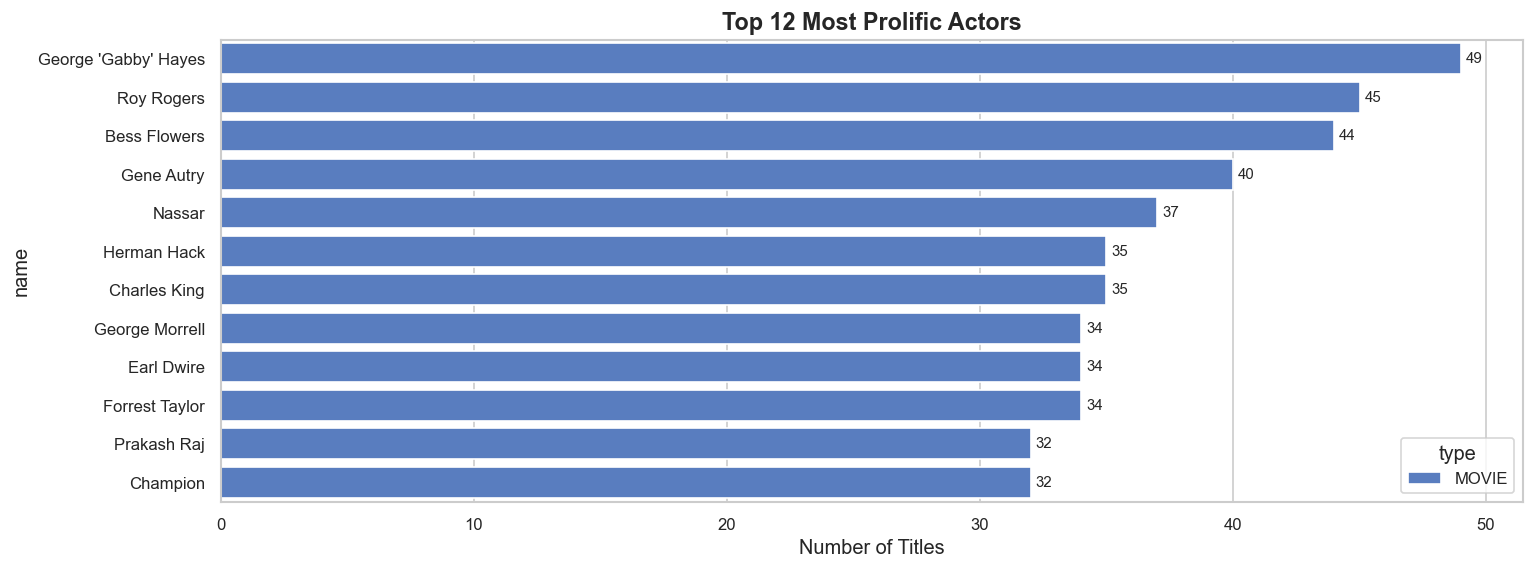

                      count
name                       
George 'Gabby' Hayes     49
Roy Rogers               45
Bess Flowers             44
Gene Autry               40
Nassar                   37
Herman Hack              35
Charles King             35
George Morrell           34
Earl Dwire               34
Forrest Taylor           34
Prakash Raj              32
Champion                 32


In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'credits' and 'df' are your DataFrames
merged = credits.merge(df[['id', 'title', 'type', 'imdb_score']], on='id', how='inner')
actors = merged[merged['role'] == 'ACTOR']

# Explode the 'name' column
actors = actors.explode('name')

# Get the names of the top 12 actors
top_actors_names = actors['name'].value_counts().head(12).index.tolist()

# Filter the actors DataFrame
top_actors_data = actors[actors['name'].isin(top_actors_names)]

fig, axes = plt.subplots(figsize=(14, 5))

# Use Seaborn countplot
# We assign the result to 'axes' directly, as sns.countplot returns the Axes object
sns.countplot(
    data=top_actors_data, 
    y='name',
    hue='type', 
    ax=axes, 
    order=top_actors_names, 
    edgecolor='white'
)

# Iterate through the containers in the axes to label the bars
for container in axes.containers:
    axes.bar_label(container, padding=3, fontsize=9)

axes.set_title('Top 12 Most Prolific Actors', fontweight='bold')
axes.set_xlabel('Number of Titles')

plt.show()
print(pd.DataFrame(actors['name'].value_counts().head(12)))

##### 1. Why did you pick the specific chart?

Count Plot is a specific type  of a bar chart is to compare values across different categories. In this case, the chart is used to compare the number of titles acted by the top 12 most prolific actors. The chart is a horizontal bar chart, which is often used to display data in a more readable format.

##### 2. What is/are the insight(s) found from the chart?

The chart show that the top 12 most prolific actors are all actors, with the most prolific actor being George 'Gabby' Hayes, who has acted in 49 titles. So it says that actors have the highest number of titles than shows. This respective actor is attracted by the many audiance.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This insight is very usefull for the future production movies and shows it says that the respective actor is attracted by the many audiance. This insight can help the business to promote and market the movies and shows more effectively, which can help to increase revenue and improve the overall success of the business.

#### Chart - 12 - Most prolific directors

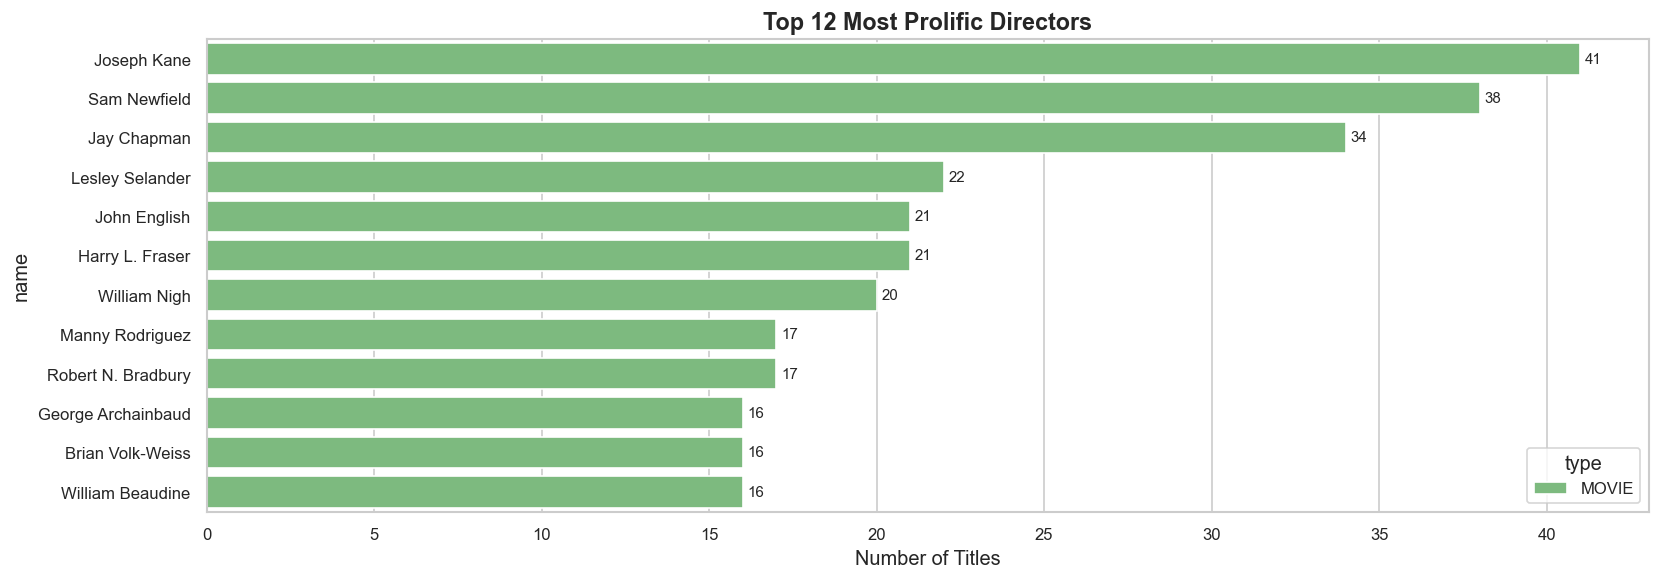

                    count
name                     
Joseph Kane            41
Sam Newfield           38
Jay Chapman            34
Lesley Selander        22
John English           21
Harry L. Fraser        21
William Nigh           20
Manny Rodriguez        17
Robert N. Bradbury     17
George Archainbaud     16
Brian Volk-Weiss       16
William Beaudine       16


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter for directors
directors = merged[merged['role'] == 'DIRECTOR']

# 2. Get the names of the top 12 directors to filter the DataFrame
top_directors_names = directors['name'].value_counts().head(12).index.tolist()

# 3. Filter the 'directors' DataFrame to only include these top 12 names
top_directors_data = directors[directors['name'].isin(top_directors_names)]

fig, axes = plt.subplots(figsize=(14, 5))

# 4. Use Seaborn countplot
sns.countplot(
    data=top_directors_data, 
    y='name',
    hue='type',       # Now 'type' is available because we are using the raw DataFrame
    ax=axes, palette='Greens',
    order=top_directors_names, 
    edgecolor='white'
)

# 5. Fix for bar_label: Iterate through containers
for container in axes.containers:
    axes.bar_label(container, padding=3, fontsize=9)

axes.set_title('Top 12 Most Prolific Directors', fontweight='bold')
axes.set_xlabel('Number of Titles')
plt.tight_layout()
plt.show()
print(pd.DataFrame(directors['name'].value_counts().head(12)))



##### 1. Why did you pick the specific chart?

Count Plot is a specific type  of a bar chart is to compare values across different categories. In this case, the chart is used to compare the number of titles directed by the top 12 most prolific directors. The chart is a horizontal bar chart, which is often used to display data in a more readable format.

##### 2. What is/are the insight(s) found from the chart?

The chart show that the top 12 most prolific directors are all directors, with the most prolific director being Joseph Kane, who has directed 41 titles. So it says that directors have the highest number of titles than shows. This respective director is attracted by the many audiance.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This insight is very usefull for the future production movies and shows it says that the respective director is attracted by the many audiance. This insight can help the business to promote and market the movies and shows more effectively, which can help to increase revenue and improve the overall success of the business.

#### Chart - 13 -  Age Certification Analysis

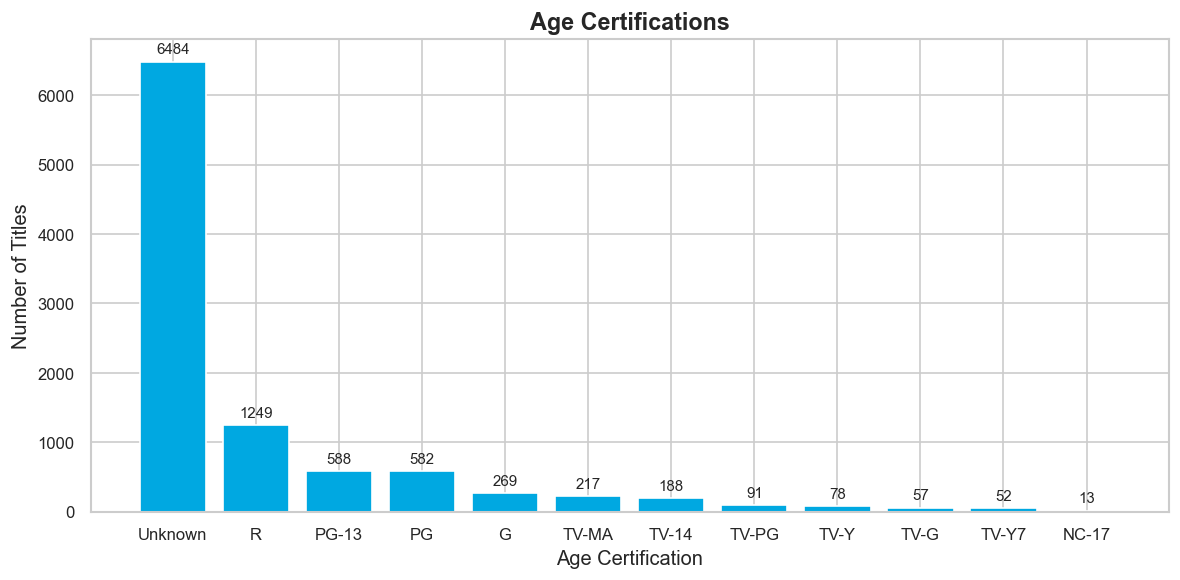

In [30]:
# Chart - 13 visualization code
cert_counts = df['age_certification'].value_counts()
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(cert_counts.index, cert_counts.values, color=PRIME_BLUE, edgecolor='white')
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title('Age Certifications', fontweight='bold')
ax.set_xlabel('Age Certification')
ax.set_ylabel('Number of Titles')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

bar chart is a specific type  of a bar chart is to compare values across different categories. In this case, the chart is used to compare the number of titles with different age certifications. The chart is a horizontal bar chart, which is often used to display data in a more readable format.

##### 2. What is/are the insight(s) found from the chart?

The chart show that the most title not have the age certification .only few tiles got age certification based on that 'R' (Restricted) is the most common age certification(1249), which is followed by 'PG-13' (Parental Guidance Suggested) and 'PG' (Parental Guidance). audiance like the titles with no age certifications

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Insight shows that the which type of age certification is most common among the titles. This insight can help the business to promote and market the movies and shows more effectively, which can help to increase revenue and improve the overall success of the business.

#### Chart - 14 - Correlation Heatmap - All Numeric Features

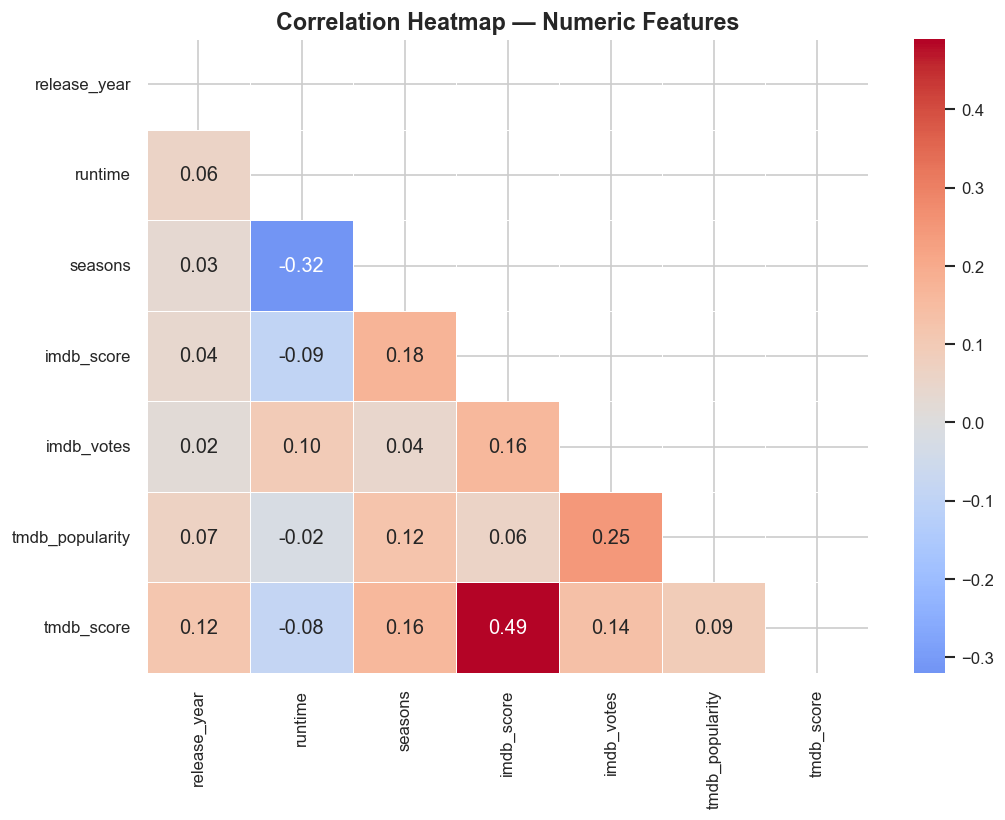

In [31]:
# Correlation Heatmap visualization code
numeric_cols = ['release_year', 'runtime', 'seasons', 'imdb_score',
                'imdb_votes', 'tmdb_popularity', 'tmdb_score']

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Correlation Heatmap — Numeric Features', fontweight='bold')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

We use heatmaps primarily to visualize complex data sets, identify patterns, and detect correlations that would be difficult to see in a raw table of numbers

##### 2. What is/are the insight(s) found from the chart?

The chart shows that the tmbd_score and imdb_score have a high positive correlation(0.49).seasion and runtime have the negative correlation(-0.32). This means that as the number of seasons increases, the runtime of the show decreases. This insight can help the business to make informed decisions about the production of movies and shows, such as how many seasons to produce and how long each season should be.

#### Chart - 15 - Pair Plot - Ratings & Popularity Analysis

<Figure size 1440x1200 with 0 Axes>

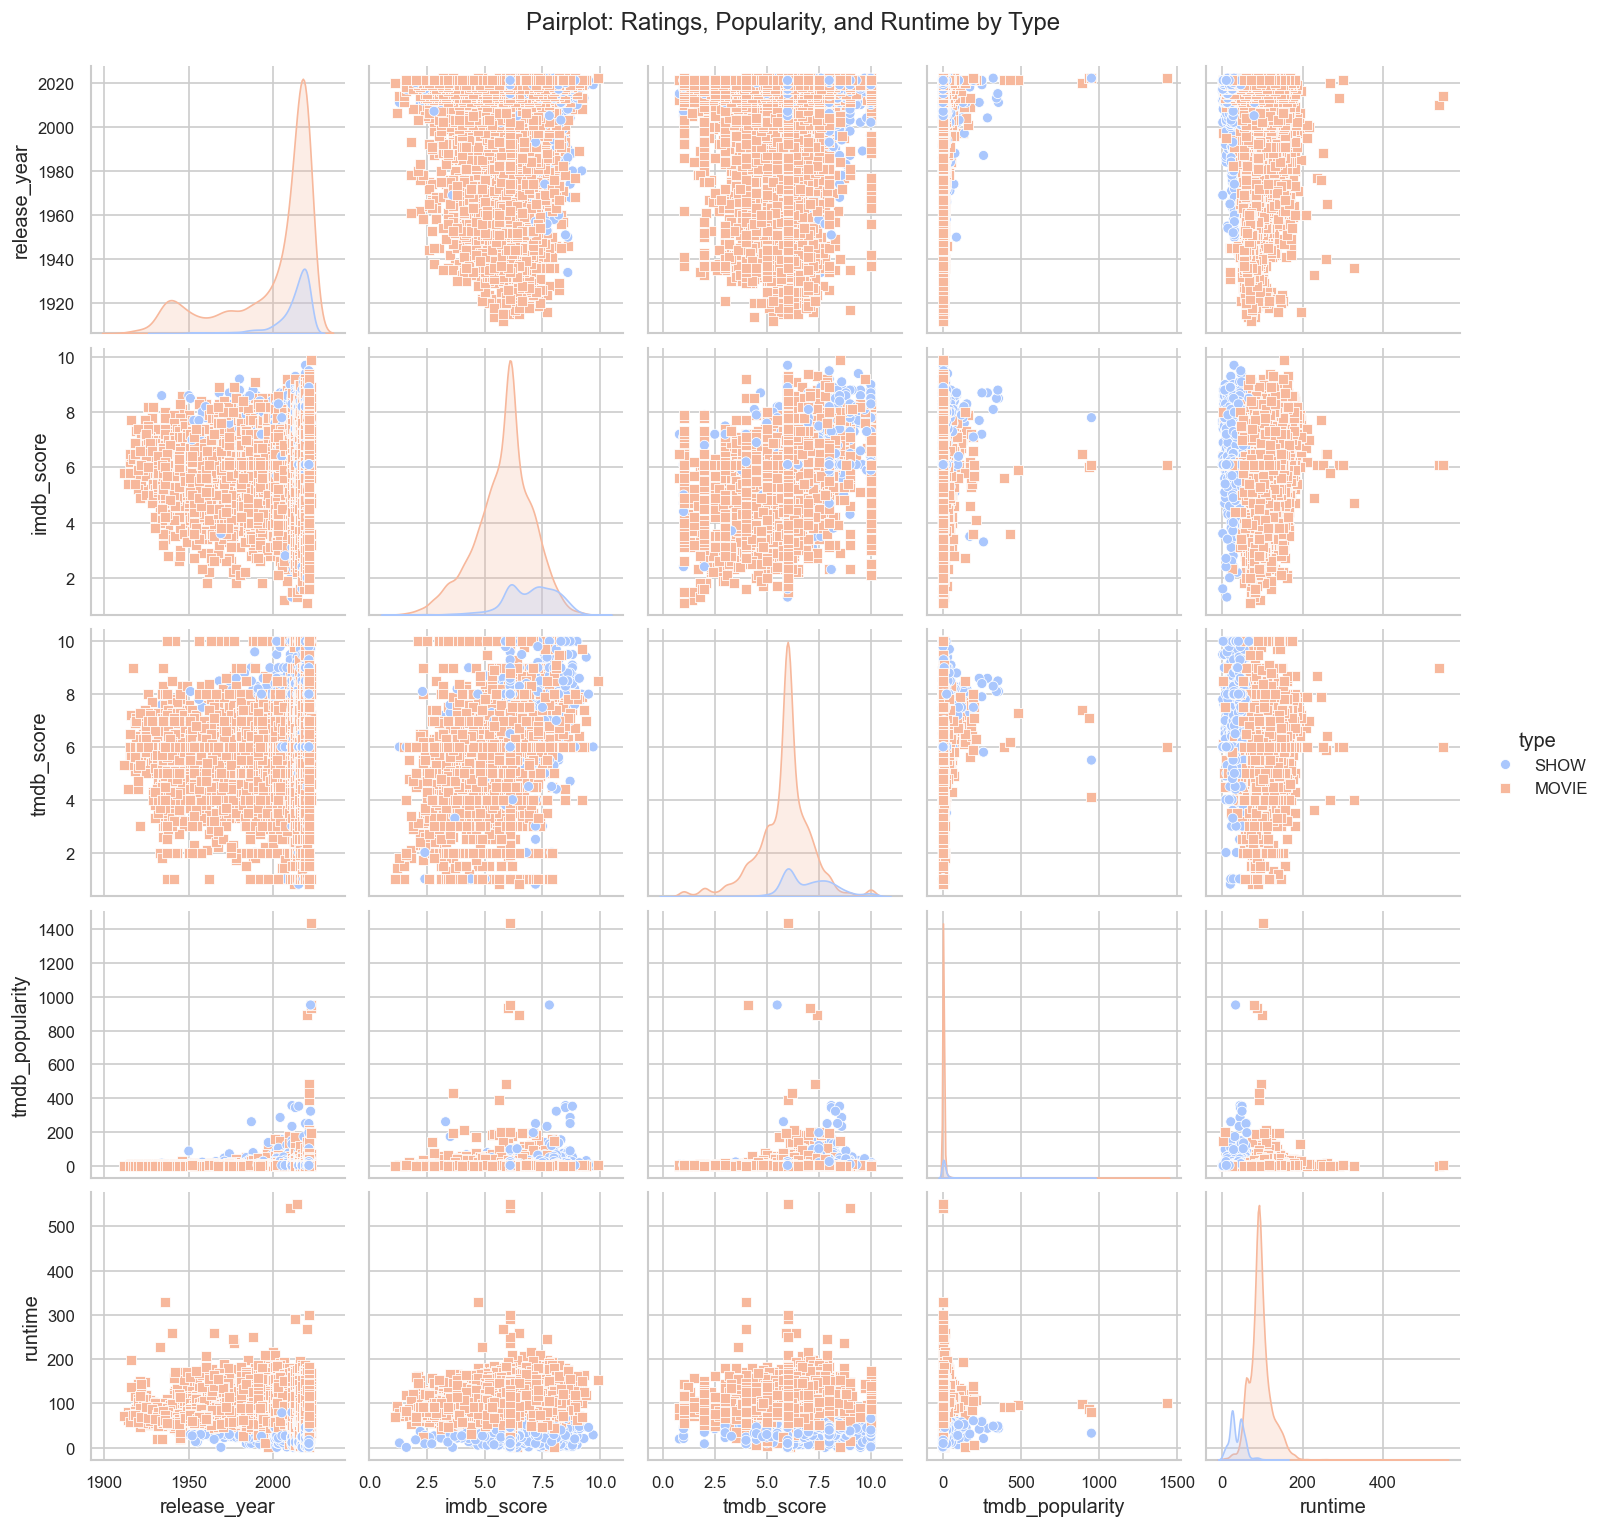

In [32]:
# Pair Plot visualization code
# --- PAIRPLOT 1: Ratings & Popularity Analysis (Movies vs Shows)
plot_df = df[['type', 'release_year', 'runtime', 'imdb_score', 'tmdb_popularity', 'tmdb_score']]
plt.figure(figsize=(12, 10))
sns.pairplot(
    plot_df,
    vars=['release_year','imdb_score', 'tmdb_score', 'tmdb_popularity', 'runtime'],
    hue='type',  # Differentiates between MOVIE and SHOW
    palette='coolwarm',
    markers=["o", "s"],
    height=2.5
)
plt.suptitle('Pairplot: Ratings, Popularity, and Runtime by Type', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

Pairplot is a great tool for visualizing the relationships between multiple variables in a dataset. It allows you to see how different variables are related to each other, and how they change over time or across different groups. It is a great way to get a quick overview of the data and identify patterns or trends.


##### 2. What is/are the insight(s) found from the chart?

imdb_score vs tmdb_score
* You will likely see a strong positive correlation. Titles that are rated highly on IMDb also tend to be rated highly on TMDB. This validates that "good content" is generally agreed upon by both critics and general audiences.
* Tv shows has  high  score on both platforms

tmdb_popularity vs imdb_score
* High IMDb Score but Low Popularity. This represents the older movies (1920s-1950s) in your dataset They are highly rated but are not currently "trending."
* Tv shows are more rated but less popular

runtime vs release_year
* The variance in movie runtime has increased over time. Older movies tend to have tighter runtimes (often 80-100 mins), while modern movies show a wider spread (some short, some very long epics).
*Tv show are started telecasting from 1950s but very  short runtime compared to movies

tmdb_popularity vs release_year

* High popularity in 2010s and 2020s. This is likely due to the rise of streaming services and the availability of more content in these years.




#### Chart - 16 - Pair Plot - TV Show Specific Analysis

<Figure size 1200x960 with 0 Axes>

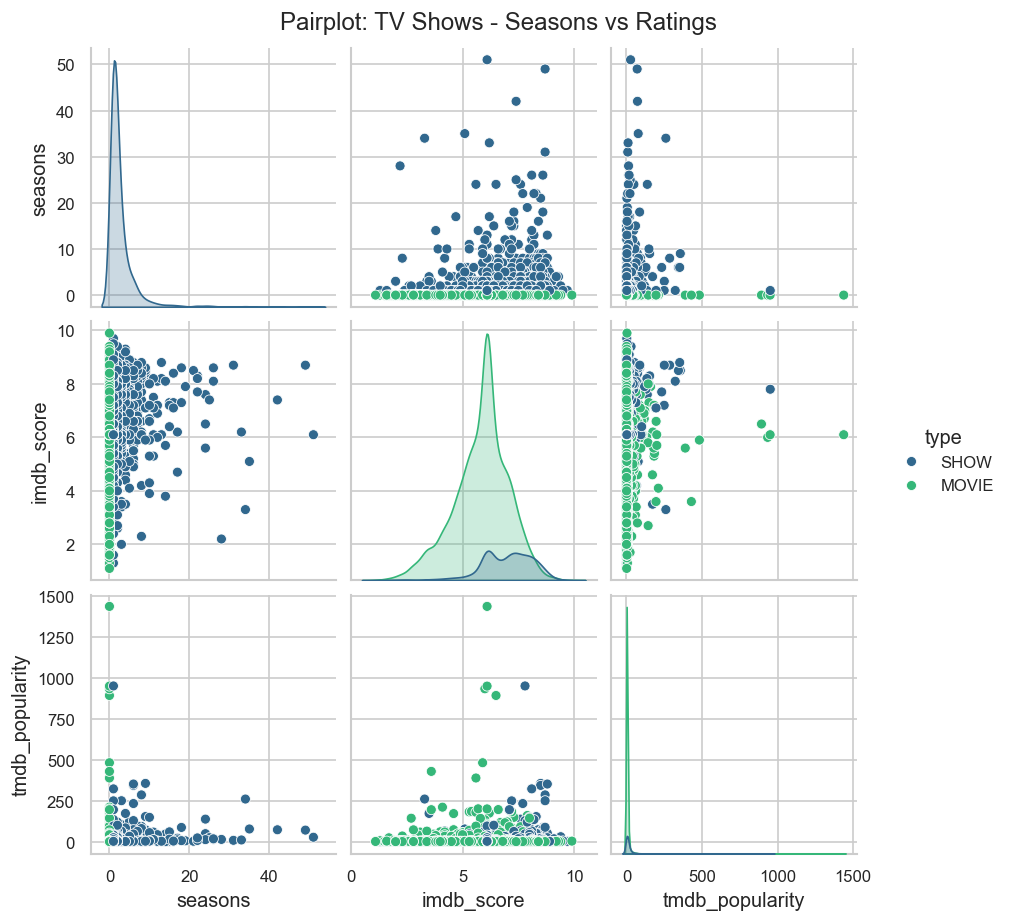

In [33]:
# --- PAIRPLOT 2
# Filtering only for Shows to analyze seasons vs ratings
shows_df = df[['type','seasons', 'imdb_score', 'tmdb_popularity', 'tmdb_score']].dropna()

plt.figure(figsize=(10, 8))
sns.pairplot(
    shows_df,
    vars=['seasons', 'imdb_score', 'tmdb_popularity'],
    hue='type',
    palette='viridis',
    height=2.5
)
plt.suptitle('Pairplot: TV Shows - Seasons vs Ratings', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

Pairplot is a great tool for visualizing the relationships between multiple variables in a dataset. It allows you to see how different variables are related to each other, and how they change over time or across different groups. It is a great way to get a quick overview of the data and identify patterns or trends.


##### 2. What is/are the insight(s) found from the chart?

seasons vs imdb_score
* shows have high seasons if the seasons increases the score also increases.
* Movies have high score

seasons vs tmdb_score
* Movies have the high score.
* Shows seasons increses no growth on the scores it maintaining the same

## Summary Statistics

In [34]:
print('=' * 55)
print('     AMAZON PRIME — EDA SUMMARY STATISTICS')
print('=' * 55)
print(f"  Total titles analysed    : {len(df):,}")
print(f"  Movies                   : {(df['type']=='MOVIE').sum():,}")
print(f"  TV Shows                 : {(df['type']=='SHOW').sum():,}")
print(f"  Unique genres            : {df.explode('genres_list')['genres_list'].nunique()}")
print(f"  Production countries     : {df.explode('countries_list')['countries_list'].nunique()}")
print(f"  Year range               : {df['release_year'].min()} – {df['release_year'].max()}")
print(f"  Avg IMDb score           : {df['imdb_score'].mean():.2f}")
print(f"  Median IMDb score        : {df['imdb_score'].median():.2f}")
print(f"  Highest rated (10k+ votes): {df[df['imdb_votes']>10000].nlargest(1,'imdb_score')['title'].values[0]}")
print(f"  Most popular (TMDB)      : {df.nlargest(1,'tmdb_popularity')['title'].values[0]}")
print(f"  Most common genre        : {genre_counts.index[0]}")
print(f"  Top production country   : {country_counts.index[0]}")
print('=' * 55)

     AMAZON PRIME — EDA SUMMARY STATISTICS
  Total titles analysed    : 9,868
  Movies                   : 8,511
  TV Shows                 : 1,357
  Unique genres            : 19
  Production countries     : 117
  Year range               : 1912 – 2022
  Avg IMDb score           : 5.99
  Median IMDb score        : 6.10
  Highest rated (10k+ votes): The Chosen
  Most popular (TMDB)      : All the Old Knives
  Most common genre        : drama
  Top production country   : US


## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

To address these challenges, a comprehensive data analytics solution was implemented using Python (Pandas, Matplotlib, Seaborn). The solution follows a four-step analytical framework:

A. Data Preprocessing & Cleaning:
Ingestion: Merged titles.csv and credits.csv to link performance metrics with cast/crew data.
Transformation: Converted string-formatted lists (e.g., "['comedy', 'drama']") into workable data structures and handled missing values to ensure data integrity.

B. Descriptive Analytics (Content Trends):
Genre Analysis: Identified the most frequent genres (e.g., Drama, Comedy) and correlated them with average IMDb scores to find "high-value" genres.
Temporal Analysis: Analyzed release years to visualize the shift from classic cinema (1920s-1950s) to modern content, highlighting the library's historical depth.
Demographic Targeting: Visualized age_certification to understand which audience groups (PG, R, TV-MA) are most catered to.

C. Performance Analytics (Audience Sentiment):
Correlation Analysis: Examined the relationship between tmdb_popularity and imdb_score to see if "hype" matches "quality."
Top Talent Identification: Aggregated credits data to list the top 10 actors and directors based on their frequency of appearance and the average rating of their titles.

D. Strategic Recommendations:
Acquisition Strategy: Recommended increasing investment in genres that show high scores but lower volume (untapped potential).
Marketing Strategy: Suggested curating "Classic Cinema" collections for older demographics, given the high volume of mid-20th-century titles in the dataset.

# **Conclusion**

The analysis of the Amazon Prime Video catalog reveals a platform that is heavily skewed towards US-produced content, with a rich repository of classic cinema alongside modern blockbusters.Drama and Comedy are the pillars of the library, suggesting a broad, family-friendly, and general audience appeal rather than niche targeting.There is a distinct set of titles that are highly popular but may have moderate IMDb scores, indicating a "guilty pleasure" segment of the audience that differs from the "critical acclaim" segment.A small group of actors and directors appears disproportionately in the library. Leveraging these familiar faces in recommendation algorithms could drive higher engagement. The presence of films from the 1920s-1950s (e.g., The General, It's a Wonderful Life) is a unique differentiator that Prime can market to film enthusiasts, a niche less emphasized by competitors focused on original streaming series.By aligning content acquisition with the identified high-performing genres and utilizing the deep catalog of classic films as a marketing hook, Amazon Prime Video can optimize user retention and improve the overall satisfaction of its subscriber base. The project successfully transforms raw metadata into actionable business intelligence.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***